<div style="display:flex; justify-content:space-between; align-items:center; width:100%; margin:8px 0 24px 0;">
  <div style="text-align:left;">
    <img src="https://www.ec-nantes.fr/medias/photo/logocn-rvb_1648479844750-png?ID_FICHE=178994&amp;INLINE=FALSE" alt="Centrale Nantes" style="height:72px; width:auto;">
  </div>
  <div style="text-align:right; font-size:18px; font-weight:600; color:#17324d; line-height:1.35;">
    MSc. CORO DASSIP
  </div>
</div>

<div style="border:2px solid #333; padding:14px 20px; margin:15px auto 25px auto; width:85%; max-width:900px; box-sizing:border-box; text-align:center;">
  <h1 style="margin:0;"><b>Deep Learning for MNIST Classification</b></h1>
</div>

This notebook is the executable source of truth for the MNIST deep-learning laboratory. Each Required Task from 1 to 13 is presented as a numbered section with its corresponding code immediately below it. The companion notebooks contain the aligned problem definition, requirements, and theory notebook.

## Setup — Environment and Configuration

Shared imports, deterministic seeds, device selection, experiment constants, and output directory used by Tasks 1–13.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from mnist import MNIST
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

BATCH_SIZE = 512
HIDDEN_SIZES = [128, 256, 512]
EPOCHS = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-3
N_CLASSES = 10
IMAGE_SIZE = 28
INPUT_DIM = IMAGE_SIZE * IMAGE_SIZE

OUTPUT_DIR = Path("../outputs/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.14.0+cu130
Device: cpu


## 1. Validate MNIST Data and Output Paths

Verify that all four local MNIST IDX files exist and prepare the repository-relative output directory.

In [2]:
DATA_DIR = Path("../data")

REQUIRED_MNIST_FILES = [
    "train-images-idx3-ubyte",
    "train-labels-idx1-ubyte",
    "t10k-images-idx3-ubyte",
    "t10k-labels-idx1-ubyte",
]

missing_files = [
    name
    for name in REQUIRED_MNIST_FILES
    if not (DATA_DIR / name).exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing MNIST files: " + ", ".join(missing_files)
    )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"MNIST data directory: {DATA_DIR}")
print(f"Figures directory: {OUTPUT_DIR}")
print("All required MNIST files are present.")

MNIST data directory: ../data
Figures directory: ../outputs/figures
All required MNIST files are present.


## 2. Build the MNIST Dataset and Mini-Batch Pipeline

Create a PyTorch-compatible dataset that normalizes raw MNIST pixels to $[0,1]$ and a loader factory that constructs deterministic training/testing mini-batches.

In [3]:
class MNISTDataset(Dataset):
    """Local IDX-backed MNIST dataset with [0, 1] pixel normalization."""

    image_size = IMAGE_SIZE

    def __init__(self, partition, mnist_dir):
        if partition not in ("training", "testing"):
            raise ValueError(
                f"{partition!r} is not a valid partition."
            )

        mnist = MNIST(str(mnist_dir))
        parser = getattr(mnist, f"load_{partition}")

        self.images, self.labels = parser()
        self.nimages = len(self.images)

    def __len__(self):
        return self.nimages

    def __getitem__(self, index):
        image = (
            np.asarray(
                self.images[index],
                dtype=np.float32,
            )
            / 255.0
        )

        label = int(self.labels[index])

        return {
            "image": image,
            "label": label,
        }

    @staticmethod
    def collate_fn(data_batch):
        images = np.stack(
            [item["image"] for item in data_batch],
            axis=0,
        ).astype(np.float32)

        labels = np.asarray(
            [item["label"] for item in data_batch],
            dtype=np.int64,
        )

        return {
            "image": images,
            "label": labels,
        }


def build_dataset_and_loader(
    batch_size,
    partition,
    data_dir,
):
    """Create one MNIST dataset and its DataLoader."""
    dataset = MNISTDataset(
        partition=partition,
        mnist_dir=data_dir,
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=(partition == "training"),
        num_workers=0,
        collate_fn=dataset.collate_fn,
    )

    return dataset, loader

print("MNIST dataset and DataLoader pipeline defined.")

MNIST dataset and DataLoader pipeline defined.


## 3. Load and Validate Training and Testing Data

Instantiate the training/test datasets and loaders, then validate the expected MNIST sizes, flattened image dimension, label range, and normalized pixel range.

In [4]:
train_dataset, train_loader = build_dataset_and_loader(
    batch_size=BATCH_SIZE,
    partition="training",
    data_dir=DATA_DIR,
)

test_dataset, test_loader = build_dataset_and_loader(
    batch_size=BATCH_SIZE,
    partition="testing",
    data_dir=DATA_DIR,
)

if len(train_dataset) != 60_000:
    raise ValueError(
        f"Expected 60,000 training images; found {len(train_dataset):,}."
    )

if len(test_dataset) != 10_000:
    raise ValueError(
        f"Expected 10,000 test images; found {len(test_dataset):,}."
    )

sample = train_dataset[0]

if sample["image"].shape != (INPUT_DIM,):
    raise ValueError(
        f"Expected flattened image shape {(INPUT_DIM,)}; "
        f"found {sample['image'].shape}."
    )

if not (0 <= sample["label"] < N_CLASSES):
    raise ValueError("MNIST label is outside the expected range 0–9.")

if (
    sample["image"].min() < 0.0
    or sample["image"].max() > 1.0
):
    raise ValueError("MNIST pixels are not normalized to [0, 1].")

print(f"Training images: {len(train_dataset):,}")
print(f"Testing images: {len(test_dataset):,}")
print(f"Flattened image shape: {sample['image'].shape}")
print(f"Pixel range: [{sample['image'].min():.3f}, {sample['image'].max():.3f}]")

Training images: 60,000
Testing images: 10,000
Flattened image shape: (784,)
Pixel range: [0.000, 1.000]


## 4. Visualize Representative MNIST Samples

Inspect representative normalized digits and save the sample-batch diagnostic figure.

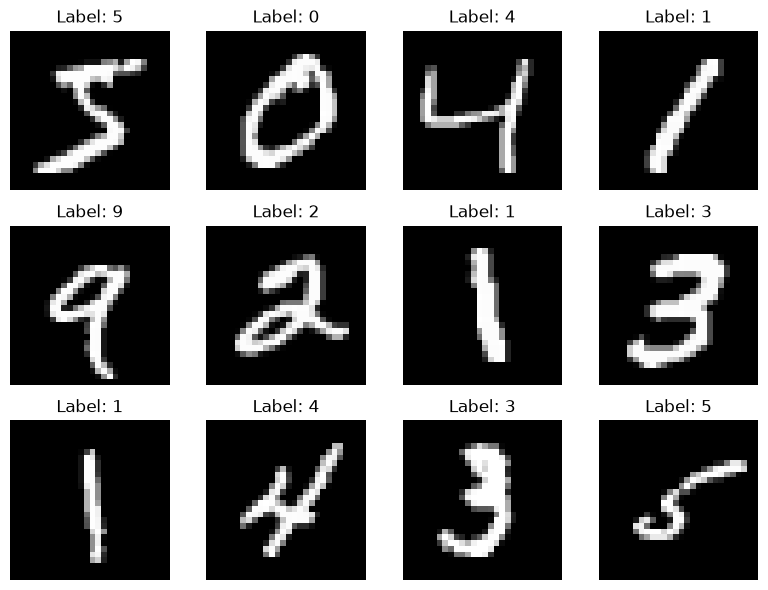

In [5]:
sample_indices = np.arange(12)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(8, 6),
)

axes = axes.reshape(-1)

for ax, index in zip(
    axes,
    sample_indices,
):
    item = train_dataset[index]

    ax.imshow(
        item["image"].reshape(
            IMAGE_SIZE,
            IMAGE_SIZE,
        ),
        cmap="gray",
    )

    ax.set_title(
        f"Label: {item['label']}"
    )
    ax.axis("off")

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "mnist_sample_batch.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 5. Define the One-Hidden-Layer MLP Classifier

Implement the common $784\rightarrow H\rightarrow10$ architecture with an optional Batch Normalization layer, ReLU non-linearity, raw logits for Cross-Entropy training, and Softmax decoding for inference.

In [6]:
class MNISTClassifier(nn.Module):
    """One-hidden-layer MLP used for all three experiments."""

    def __init__(
        self,
        hidden_size,
        nclasses=N_CLASSES,
        imsize=IMAGE_SIZE,
        use_batch_norm=True,
    ):
        super().__init__()

        layers = [
            nn.Linear(
                imsize * imsize,
                hidden_size,
            ),
        ]

        if use_batch_norm:
            layers.append(
                nn.BatchNorm1d(
                    hidden_size
                )
            )

        layers.extend(
            [
                nn.ReLU(),
                nn.Linear(
                    hidden_size,
                    nclasses,
                ),
            ]
        )

        self.net = nn.Sequential(*layers)
        self.loss_fn = nn.functional.cross_entropy

    def forward(self, data_dict):
        logits = self.net(
            data_dict["image"]
        )

        if self.training:
            loss = self.loss_fn(
                logits,
                data_dict["label"],
            )

            return {
                "loss": loss,
                "logits": logits,
            }

        predicted_class, confidence = (
            self.decode_prediction(logits)
        )

        return {
            "cls": predicted_class,
            "prob": confidence,
            "logits": logits,
        }

    @staticmethod
    def decode_prediction(logits):
        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        confidence, predicted_class = torch.max(
            probabilities,
            dim=1,
        )

        return predicted_class, confidence

print("MNISTClassifier defined.")

MNISTClassifier defined.


## 6. Verify the Model Architecture and Forward Pass

Instantiate a representative 256-neuron model and verify the architecture, finite loss, and expected $B\times10$ logit shape before full training.

In [7]:
example_model = MNISTClassifier(
    hidden_size=256,
).to(device)

print(example_model)

example_batch = next(
    iter(train_loader)
)

example_batch = {
    "image": torch.from_numpy(
        example_batch["image"]
    ).to(device),
    "label": torch.from_numpy(
        example_batch["label"]
    ).to(device),
}

example_model.train()
example_output = example_model(
    example_batch
)

if not torch.isfinite(
    example_output["loss"]
):
    raise ValueError(
        "Example forward pass produced a non-finite loss."
    )

expected_shape = (
    example_batch["image"].shape[0],
    N_CLASSES,
)

if tuple(
    example_output["logits"].shape
) != expected_shape:
    raise ValueError(
        "Unexpected logit shape: "
        f"{tuple(example_output['logits'].shape)}"
    )

print(
    f"Example training loss: "
    f"{example_output['loss'].item():.4f}"
)
print(
    f"Logit shape: "
    f"{tuple(example_output['logits'].shape)}"
)

MNISTClassifier(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Example training loss: 2.3383
Logit shape: (512, 10)


## 7. Define Training and Evaluation Utilities

Create reusable batch transfer, optimization, and inference functions with explicit train/eval modes and no-gradient evaluation.

In [8]:
def prepare_batch(
    batch,
    target_device,
):
    """Convert NumPy mini-batches to PyTorch tensors on the target device."""
    return {
        "image": torch.from_numpy(
            batch["image"]
        ).to(target_device),
        "label": torch.from_numpy(
            batch["label"]
        ).to(target_device),
    }


def train_model(
    model,
    train_loader,
    optimizer,
    epochs,
    target_device,
):
    """Train one model and return mean Cross-Entropy loss per epoch."""
    epoch_losses = []

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        sample_count = 0

        progress = tqdm(
            train_loader,
            desc=f"Epoch {epoch + 1}/{epochs}",
            leave=False,
        )

        for batch in progress:
            batch = prepare_batch(
                batch,
                target_device,
            )

            optimizer.zero_grad()

            output = model(batch)
            loss = output["loss"]

            loss.backward()
            optimizer.step()

            current_batch_size = (
                batch["image"].shape[0]
            )

            running_loss += (
                loss.item()
                * current_batch_size
            )

            sample_count += (
                current_batch_size
            )

        mean_loss = (
            running_loss
            / sample_count
        )

        epoch_losses.append(
            mean_loss
        )

    return epoch_losses


@torch.no_grad()
def evaluate_model(
    model,
    data_loader,
    target_device,
):
    """Evaluate one model and return predictions, confidence and accuracy."""
    model.eval()

    all_classes = []
    all_probabilities = []
    all_labels = []
    all_logits = []

    for batch in data_loader:
        batch = prepare_batch(
            batch,
            target_device,
        )

        output = model(batch)

        all_classes.append(
            output["cls"].cpu()
        )
        all_probabilities.append(
            output["prob"].cpu()
        )
        all_labels.append(
            batch["label"].cpu()
        )
        all_logits.append(
            output["logits"].cpu()
        )

    classes = torch.cat(
        all_classes
    )
    probabilities = torch.cat(
        all_probabilities
    )
    labels = torch.cat(
        all_labels
    )
    logits = torch.cat(
        all_logits
    )

    accuracy = (
        classes == labels
    ).float().mean().item()

    return {
        "cls": classes,
        "prob": probabilities,
        "label": labels,
        "logits": logits,
        "accuracy": accuracy,
    }

print("Training and evaluation utilities defined.")

Training and evaluation utilities defined.


## 8. Train the 128-, 256-, and 512-Neuron Models

Train the three required hidden-layer widths under the same optimization settings and evaluate every trained model on the MNIST test set.

In [9]:
models = {}
training_histories = {}
evaluation_results = {}

for hidden_size in HIDDEN_SIZES:
    print(
        f"\nTraining model: "
        f"{INPUT_DIM} → {hidden_size} → {N_CLASSES}"
    )

    torch.manual_seed(SEED)

    model = MNISTClassifier(
        hidden_size=hidden_size,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    losses = train_model(
        model=model,
        train_loader=train_loader,
        optimizer=optimizer,
        epochs=EPOCHS,
        target_device=device,
    )

    evaluation = evaluate_model(
        model=model,
        data_loader=test_loader,
        target_device=device,
    )

    models[hidden_size] = model
    training_histories[hidden_size] = losses
    evaluation_results[hidden_size] = evaluation

    print(
        f"Final training loss: "
        f"{losses[-1]:.4f}"
    )
    print(
        f"Test accuracy: "
        f"{evaluation['accuracy']:.4f}"
    )


Training model: 784 → 128 → 10


Final training loss: 0.0795
Test accuracy: 0.9718

Training model: 784 → 256 → 10


Final training loss: 0.0743
Test accuracy: 0.9718

Training model: 784 → 512 → 10


Final training loss: 0.0717
Test accuracy: 0.9726


## 9. Compare Training Loss and Test Accuracy

Compare convergence across hidden sizes, save the training-loss figure, and summarize fresh results alongside the submitted laboratory reference losses.

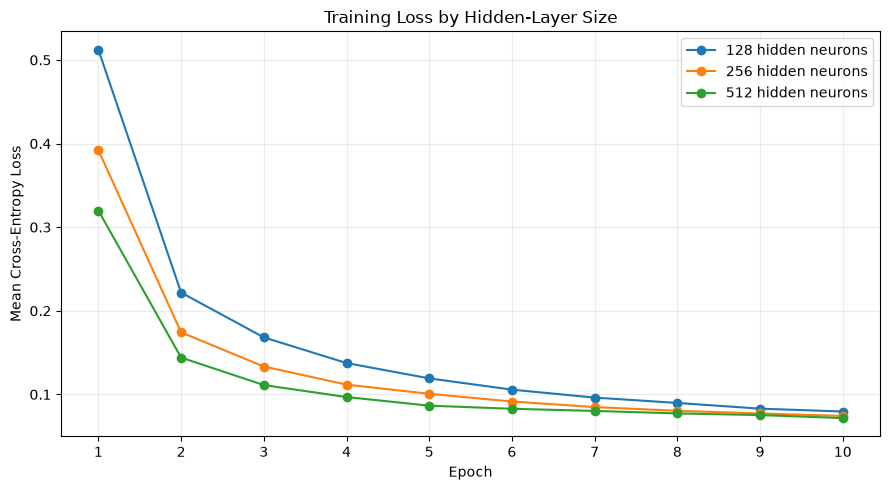

  Hidden   Final loss   Test accuracy  Reference loss
-------------------------------------------------------
     128       0.0795          0.9718          0.0753
     256       0.0743          0.9718          0.0344
     512       0.0717          0.9726          0.0394


In [10]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

for hidden_size in HIDDEN_SIZES:
    losses = training_histories[
        hidden_size
    ]

    ax.plot(
        range(1, EPOCHS + 1),
        losses,
        marker="o",
        label=(
            f"{hidden_size} hidden neurons"
        ),
    )

ax.set_title(
    "Training Loss by Hidden-Layer Size"
)
ax.set_xlabel("Epoch")
ax.set_ylabel(
    "Mean Cross-Entropy Loss"
)
ax.set_xticks(
    range(1, EPOCHS + 1)
)
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "training_loss_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

REFERENCE_REPORTED_LOSSES = {
    128: 0.0753,
    256: 0.0344,
    512: 0.0394,
}

print(
    f"{'Hidden':>8} "
    f"{'Final loss':>12} "
    f"{'Test accuracy':>15} "
    f"{'Reference loss':>15}"
)
print("-" * 55)

for hidden_size in HIDDEN_SIZES:
    final_loss = (
        training_histories[
            hidden_size
        ][-1]
    )

    test_accuracy = (
        evaluation_results[
            hidden_size
        ]["accuracy"]
    )

    print(
        f"{hidden_size:>8d} "
        f"{final_loss:>12.4f} "
        f"{test_accuracy:>15.4f} "
        f"{REFERENCE_REPORTED_LOSSES[hidden_size]:>15.4f}"
    )

## 10. Visualize Predictions and Confidence Scores

For every trained architecture, display test digits beside the complete 10-class Softmax distribution and save one prediction diagnostic figure per hidden size.

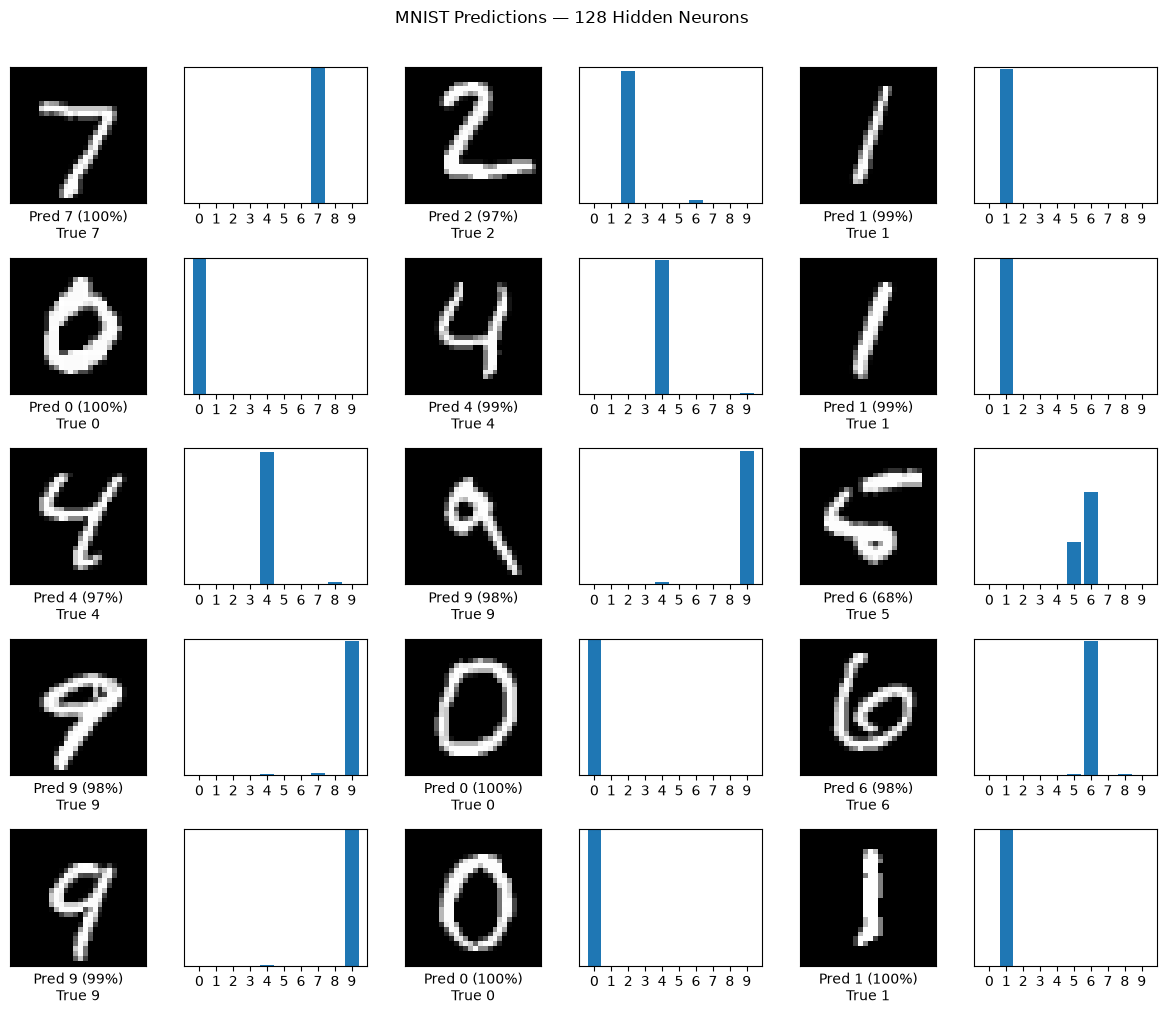

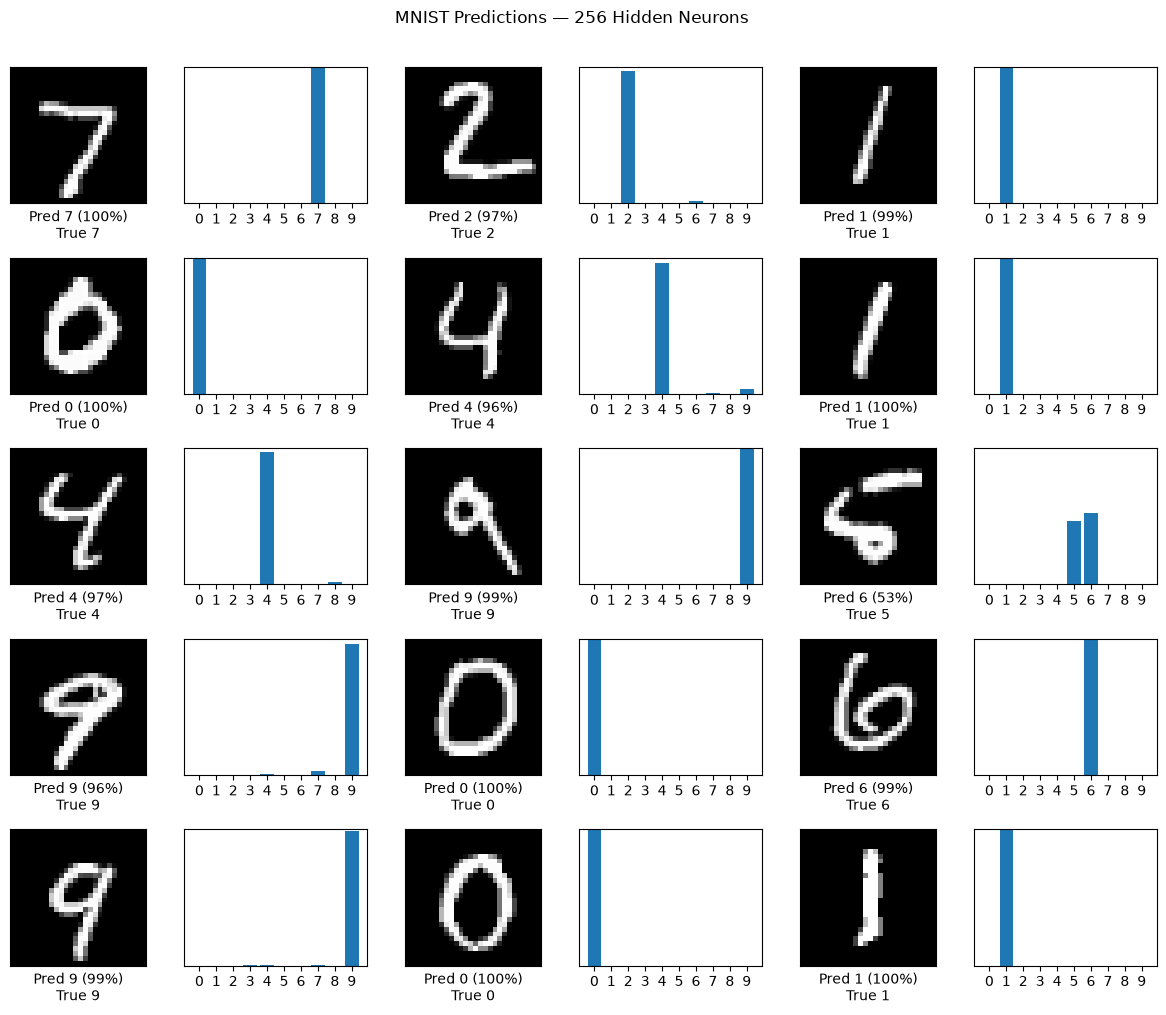

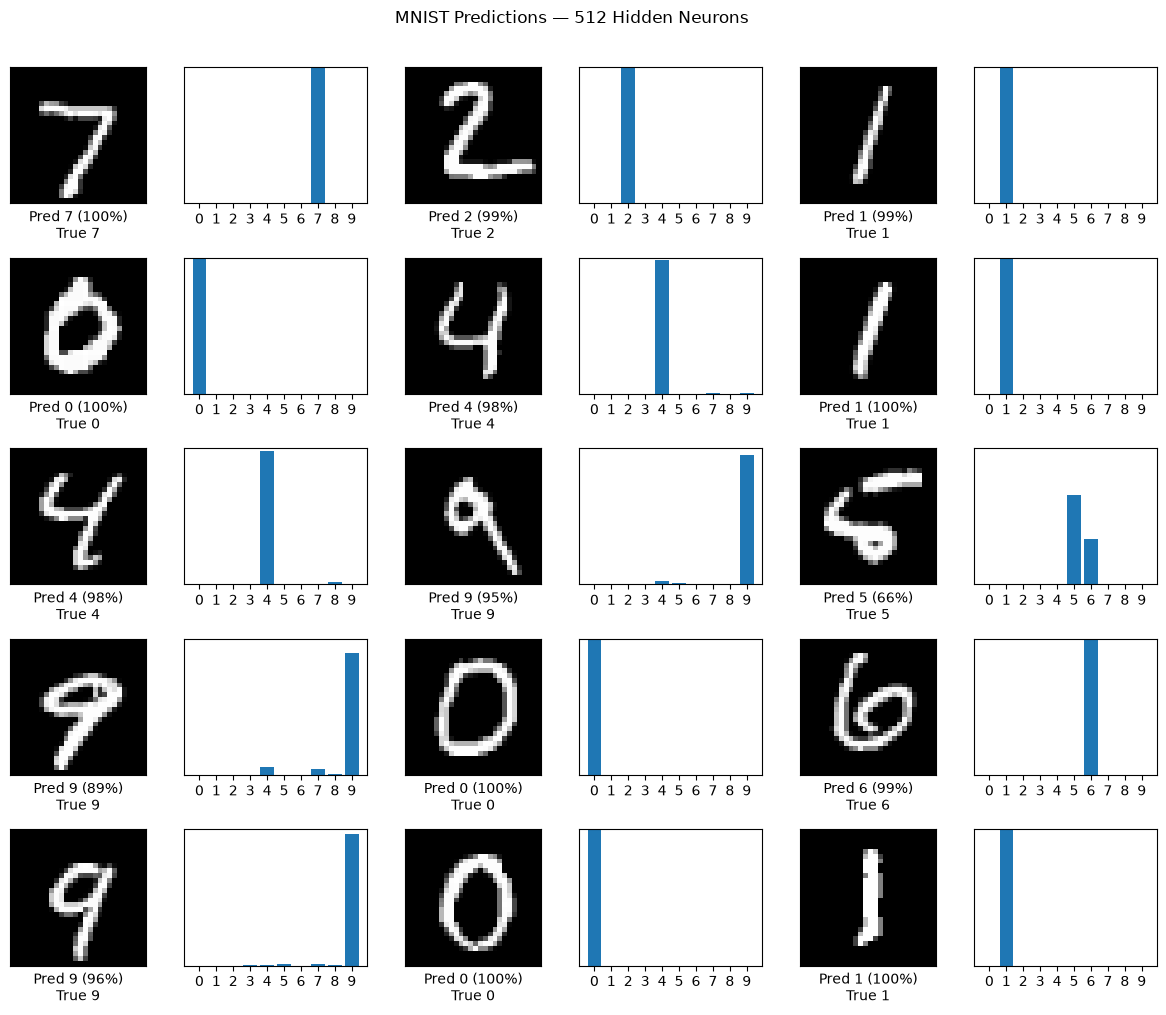

In [11]:
def plot_prediction_examples(
    model,
    dataset,
    hidden_size,
    output_path,
    n_images=15,
):
    """Visualize predictions and full Softmax distributions."""
    model.eval()

    images = np.stack(
        [
            dataset[index]["image"]
            for index in range(n_images)
        ]
    ).astype(np.float32)

    labels = np.asarray(
        [
            dataset[index]["label"]
            for index in range(n_images)
        ],
        dtype=np.int64,
    )

    batch = {
        "image": torch.from_numpy(
            images
        ).to(device),
        "label": torch.from_numpy(
            labels
        ).to(device),
    }

    with torch.no_grad():
        output = model(batch)

    probabilities = torch.softmax(
        output["logits"],
        dim=1,
    ).cpu().numpy()

    fig = plt.figure(
        figsize=(12, 10)
    )

    for index in range(n_images):
        image_axis = plt.subplot(
            5,
            6,
            2 * index + 1,
        )

        image_axis.imshow(
            images[index].reshape(
                IMAGE_SIZE,
                IMAGE_SIZE,
            ),
            cmap="gray",
        )

        predicted_label = int(
            np.argmax(
                probabilities[index]
            )
        )

        confidence = float(
            np.max(
                probabilities[index]
            )
        )

        true_label = int(
            labels[index]
        )

        image_axis.set_xlabel(
            f"Pred {predicted_label} "
            f"({confidence:.0%})\n"
            f"True {true_label}"
        )

        image_axis.set_xticks([])
        image_axis.set_yticks([])

        value_axis = plt.subplot(
            5,
            6,
            2 * index + 2,
        )

        value_axis.bar(
            range(N_CLASSES),
            probabilities[index],
        )

        value_axis.set_ylim(
            0,
            1,
        )
        value_axis.set_xticks(
            range(N_CLASSES)
        )
        value_axis.set_yticks([])

    fig.suptitle(
        f"MNIST Predictions — "
        f"{hidden_size} Hidden Neurons",
        y=1.01,
    )

    plt.tight_layout()

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


for hidden_size in HIDDEN_SIZES:
    plot_prediction_examples(
        model=models[hidden_size],
        dataset=test_dataset,
        hidden_size=hidden_size,
        output_path=(
            OUTPUT_DIR
            / f"mnist_predictions_{hidden_size}.png"
        ),
    )

## 11. Compute Confidence-Threshold Precision, Recall, and Accepted Accuracy

Treat prediction correctness as the positive event. For each confidence threshold, compute precision among accepted predictions, recall of all correct predictions, and the fraction of the full test set that is both accepted and correct.

In [12]:
def compute_confidence_curves(
    evaluation,
    n_thresholds=100,
):
    """Compute confidence-selective correctness metrics."""
    predicted_classes = (
        evaluation["cls"].numpy()
    )

    confidence = (
        evaluation["prob"].numpy()
    )

    labels = (
        evaluation["label"].numpy()
    )

    correct = (
        predicted_classes
        == labels
    )

    thresholds = np.linspace(
        0.0,
        0.99,
        n_thresholds,
    )

    precision_values = []
    recall_values = []
    accepted_accuracy_values = []

    total_correct = np.sum(
        correct
    )

    for threshold in thresholds:
        accepted = (
            confidence
            > threshold
        )

        true_positive = np.sum(
            accepted & correct
        )

        false_positive = np.sum(
            accepted & ~correct
        )

        false_negative = np.sum(
            ~accepted & correct
        )

        precision_denominator = (
            true_positive
            + false_positive
        )

        recall_denominator = (
            true_positive
            + false_negative
        )

        precision = (
            true_positive
            / precision_denominator
            if precision_denominator > 0
            else np.nan
        )

        recall = (
            true_positive
            / recall_denominator
            if recall_denominator > 0
            else 0.0
        )

        accepted_accuracy = (
            true_positive
            / len(labels)
        )

        precision_values.append(
            precision
        )
        recall_values.append(
            recall
        )
        accepted_accuracy_values.append(
            accepted_accuracy
        )

    precision_values = np.asarray(
        precision_values
    )
    recall_values = np.asarray(
        recall_values
    )
    accepted_accuracy_values = np.asarray(
        accepted_accuracy_values
    )

    order = np.argsort(
        recall_values
    )

    return {
        "thresholds": thresholds[order],
        "precision": precision_values[order],
        "recall": recall_values[order],
        "accepted_accuracy": accepted_accuracy_values[order],
        "total_correct": int(total_correct),
    }

print("Confidence-threshold evaluation utility defined.")

Confidence-threshold evaluation utility defined.


## 12. Analyze the Best Model and Save Evaluation Curves

Following the submitted laboratory criterion, analyze the configuration with the lowest final training loss and save its confidence-threshold Precision–Recall and Accepted-Accuracy–Recall curves.

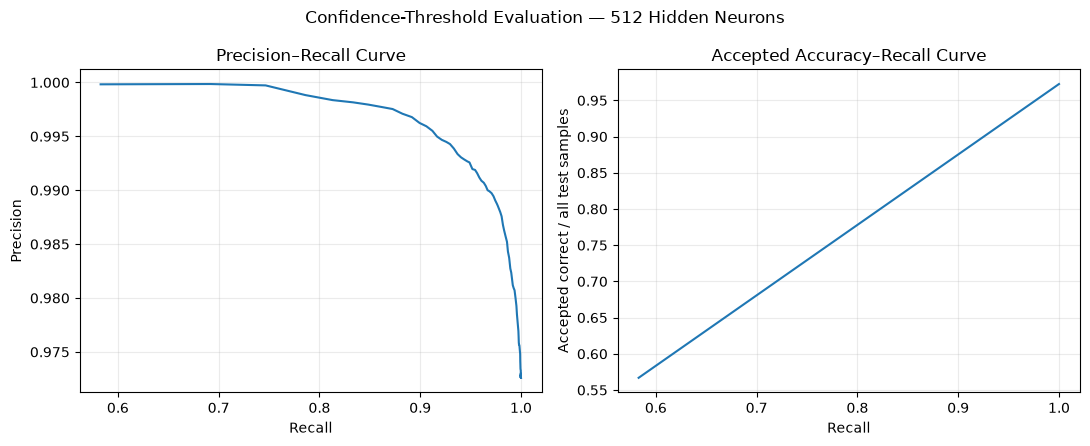

Selected hidden size: 512
Final training loss: 0.0717
Test accuracy: 0.9726


In [13]:
best_hidden_size = min(
    HIDDEN_SIZES,
    key=lambda size: (
        training_histories[
            size
        ][-1]
    ),
)

best_evaluation = (
    evaluation_results[
        best_hidden_size
    ]
)

confidence_curves = (
    compute_confidence_curves(
        best_evaluation,
        n_thresholds=100,
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
)

axes[0].plot(
    confidence_curves["recall"],
    confidence_curves["precision"],
)
axes[0].set_title(
    "Precision–Recall Curve"
)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].grid(alpha=0.25)

axes[1].plot(
    confidence_curves["recall"],
    confidence_curves[
        "accepted_accuracy"
    ],
)
axes[1].set_title(
    "Accepted Accuracy–Recall Curve"
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel(
    "Accepted correct / all test samples"
)
axes[1].grid(alpha=0.25)

fig.suptitle(
    f"Confidence-Threshold Evaluation — "
    f"{best_hidden_size} Hidden Neurons"
)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "pr_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    f"Selected hidden size: "
    f"{best_hidden_size}"
)
print(
    f"Final training loss: "
    f"{training_histories[best_hidden_size][-1]:.4f}"
)
print(
    f"Test accuracy: "
    f"{best_evaluation['accuracy']:.4f}"
)

## 13. Run Numerical and Output-file Validation Checks

Verify dataset dimensions, completed training histories, finite losses, valid test predictions/confidences, all required model configurations, and the six expected diagnostic figures.

In [14]:
if len(train_dataset) != 60_000:
    raise ValueError(
        "Training dataset size changed unexpectedly."
    )

if len(test_dataset) != 10_000:
    raise ValueError(
        "Test dataset size changed unexpectedly."
    )

if set(models) != set(HIDDEN_SIZES):
    raise ValueError(
        "Not all required MLP configurations were trained."
    )

for hidden_size in HIDDEN_SIZES:
    losses = np.asarray(
        training_histories[
            hidden_size
        ],
        dtype=float,
    )

    if losses.shape != (EPOCHS,):
        raise ValueError(
            f"Unexpected loss-history length for hidden size {hidden_size}."
        )

    if not np.all(
        np.isfinite(losses)
    ):
        raise ValueError(
            f"Non-finite training loss for hidden size {hidden_size}."
        )

    evaluation = (
        evaluation_results[
            hidden_size
        ]
    )

    if not (
        0.0
        <= evaluation["accuracy"]
        <= 1.0
    ):
        raise ValueError(
            f"Invalid test accuracy for hidden size {hidden_size}."
        )

    if (
        evaluation["cls"].shape[0]
        != len(test_dataset)
    ):
        raise ValueError(
            f"Incomplete test predictions for hidden size {hidden_size}."
        )

    probabilities = (
        evaluation["prob"].numpy()
    )

    if not np.all(
        np.isfinite(probabilities)
    ):
        raise ValueError(
            f"Non-finite confidence values for hidden size {hidden_size}."
        )

    if (
        np.any(probabilities < 0.0)
        or np.any(probabilities > 1.0)
    ):
        raise ValueError(
            f"Confidence values outside [0, 1] for hidden size {hidden_size}."
        )

REQUIRED_OUTPUTS = [
    "mnist_sample_batch.png",
    "training_loss_comparison.png",
    "mnist_predictions_128.png",
    "mnist_predictions_256.png",
    "mnist_predictions_512.png",
    "pr_accuracy_curve.png",
]

missing_outputs = [
    name
    for name in REQUIRED_OUTPUTS
    if not (
        OUTPUT_DIR / name
    ).exists()
]

if missing_outputs:
    raise FileNotFoundError(
        "Missing outputs: "
        + ", ".join(
            missing_outputs
        )
    )

print(
    "All Deep Learning validation checks passed."
)

All Deep Learning validation checks passed.


## Final Result Summary

The notebook implements and validates the complete MNIST MLP experiment using three hidden-layer widths. It preserves the laboratory architecture and optimization settings, compares training behavior and test predictions, performs confidence-threshold analysis, saves six diagnostics, and ends with explicit numerical/output validation.